1) INSTALL NECESSARY LIBRARIES

In [ ]:

!pip install -q xgboost lightgbm shap openpyxl imbalanced-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import joblib
import shap
import warnings
warnings.filterwarnings("ignore")

print("Packages loaded.")


Packages loaded.


2) LOAD DATASETS

In [ ]:

DATA_PATH = "/content/audio_dataset_translated.xlsx"  # change if needed
df = pd.read_excel(DATA_PATH)

print("Rows, columns:", df.shape)
df.head(8)


Rows, columns: (324, 16)


,Age,Pure Tone Average Air Right,Pure Tone Average Bone Right,Speech Reception Threshold Right,Most Comfortable Loudness Right,Air 250 Hz Right,Bone 500 Hz Right,Air 500 Hz Right,Bone 1000 Hz Right,Air 1000 Hz Right,Bone 2000 Hz Right,Air 2000 Hz Right,Bone 4000 Hz Right,Air 4000 Hz Right,Air 8000 Hz Right,Speech Discrimination Right
0,1,28,10,30,70,35,10,30,15,35,5,20,5,35,35,1.00
1,4,23,20,25,65,10,15,15,20,30,25,25,15,15,25,0.96
2,6,8,0,5,45,20,0,10,0,10,0,5,-5,5,15,1.00
3,6,10,-5,10,50,15,-5,15,-5,10,-5,5,-5,5,10,1.00
4,6,27,3,25,65,25,5,20,0,35,5,25,10,30,15,0.92
5,6,38,7,40,80,40,0,45,5,45,15,25,-5,55,45,0.92
6,6,38,3,40,80,40,5,35,-5,40,10,40,15,50,55,1.00
7,7,3,-8,5,45,5,-10,5,-10,0,-5,5,-10,5,0,1.00


3) DATA CLEANING AND STSNDARDIZATION

In [ ]:

df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Example: identify frequency columns automatically (detect 'hz' or numeric frequency names)
print("Columns:", df.columns.tolist())

# If necessary, rename any known columns (customize below). Example:
# df = df.rename(columns={"patientid":"patient_id", "sex/gender":"sex"})

# Drop duplicates or rows with no thresholds (if any)
df = df.drop_duplicates()
df = df.dropna(how='all')  # drop rows that are completely empty

df.shape


Columns: ['age', 'pure_tone_average_air_right', 'pure_tone_average_bone_right', 'speech_reception_threshold_right', 'most_comfortable_loudness_right', 'air_250_hz_right', 'bone_500_hz_right', 'air_500_hz_right', 'bone_1000_hz_right', 'air_1000_hz_right', 'bone_2000_hz_right', 'air_2000_hz_right', 'bone_4000_hz_right', 'air_4000_hz_right', 'air_8000_hz_right', 'speech_discrimination_right']


(323, 16)

4) EXPLORATORY DATA ANALYSIS

In [ ]:

# Show label distributions if present
label_cols = [c for c in df.columns if "label" in c or "type" in c or "severity" in c]
print("Possible label columns:", label_cols)

for col in label_cols:
    print(f"\nDistribution for {col}:")
    print(df[col].value_counts(dropna=False))

# Numeric summary for threshold columns (auto-detect frequencies)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns (first 30):", num_cols[:30])

# Visualize numeric distributions for a subset
freq_cols = [c for c in df.columns if c.startswith("freq") or c.startswith("f_") or any(str(f) in c for f in [125,250,500,1000,2000,4000,8000])]
# fallback: take numeric columns that look like thresholds if freq_cols empty
if not freq_cols:
    freq_cols = [c for c in num_cols if c not in ['age','patient_id']][:8]

print("Assumed frequency cols:", freq_cols)
df[freq_cols].describe().T


Possible label columns: []

Numeric columns (first 30): ['age', 'pure_tone_average_air_right', 'pure_tone_average_bone_right', 'speech_reception_threshold_right', 'most_comfortable_loudness_right', 'air_250_hz_right', 'bone_500_hz_right', 'air_500_hz_right', 'bone_1000_hz_right', 'air_1000_hz_right', 'bone_2000_hz_right', 'air_2000_hz_right', 'bone_4000_hz_right', 'air_4000_hz_right', 'air_8000_hz_right', 'speech_discrimination_right']
Assumed frequency cols: ['air_250_hz_right', 'bone_500_hz_right', 'air_500_hz_right', 'bone_1000_hz_right', 'air_1000_hz_right', 'bone_2000_hz_right', 'air_2000_hz_right', 'bone_4000_hz_right', 'air_4000_hz_right', 'air_8000_hz_right']


,count,mean,std,min,25%,50%,75%,max
air_250_hz_right,323.0,23.529412,15.745104,5.0,10.0,20.0,30.0,85.0
bone_500_hz_right,323.0,8.312693,12.178208,-10.0,0.0,5.0,15.0,60.0
air_500_hz_right,323.0,22.198142,15.356966,0.0,10.0,20.0,30.0,85.0
bone_1000_hz_right,323.0,9.086687,14.760571,-10.0,0.0,5.0,15.0,70.0
air_1000_hz_right,323.0,24.520124,16.727689,0.0,10.0,20.0,35.0,80.0
bone_2000_hz_right,323.0,16.191950,17.632911,-10.0,5.0,10.0,25.0,65.0
air_2000_hz_right,323.0,22.492260,18.655818,0.0,10.0,15.0,32.5,85.0
bone_4000_hz_right,323.0,16.377709,20.642770,-10.0,0.0,10.0,27.5,80.0
air_4000_hz_right,323.0,30.325077,22.373930,-5.0,10.0,25.0,45.0,90.0
air_8000_hz_right,323.0,33.869969,24.584279,-5.0,15.0,30.0,50.0,95.0


5)AVARAGE AUDIOGRAM

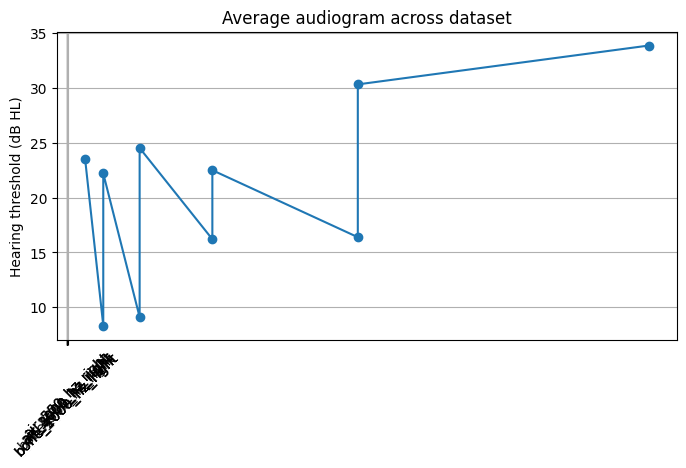

In [ ]:

if freq_cols:
    means = df[freq_cols].mean()
    plt.figure(figsize=(8,4))
    plt.plot([int(''.join(filter(str.isdigit,c))) if any(ch.isdigit() for ch in c) else i for i,c in enumerate(freq_cols)], means.values, marker='o')
    plt.xticks(range(len(freq_cols)), freq_cols, rotation=45)
    plt.ylabel("Hearing threshold (dB HL)")
    plt.title("Average audiogram across dataset")
    plt.grid(True)
    plt.show()


In [ ]:

# Adjust column names if you have explicit bone conduction columns, e.g., 'bone_500'
# Attempt to match bone conduction columns
bone_cols = [c for c in df.columns if 'bone' in c]
print("Bone columns detected:", bone_cols)

# Frequencies for air conduction (assume freq_cols are air)
air_cols = freq_cols

# Compute pure-tone average (PTA) commonly at 500, 1000, 2000Hz -> adapt if needed
def pta_row(row, freqs_subset):
    vals = [row[c] for c in freqs_subset if c in row.index and not pd.isna(row[c])]
    return np.nanmean(vals) if vals else np.nan

# pick typical 500,1000,2000 keys if present
pta_freqs = [c for c in air_cols if any(s in c for s in ['500','1000','2000'])]
if len(pta_freqs) < 3:
    pta_freqs = air_cols[:3]

df['pta_mean'] = df.apply(lambda r: pta_row(r, pta_freqs), axis=1)
df['air_mean_all'] = df[air_cols].mean(axis=1)

# if bone conduction exists: compute mean and air-bone gap
if bone_cols:
    df['bone_mean_all'] = df[bone_cols].mean(axis=1)
    df['air_bone_gap'] = df['air_mean_all'] - df['bone_mean_all']
else:
    df['air_bone_gap'] = np.nan

# slope features: difference between high and low frequency
if len(air_cols) >= 2:
    df['slope_high_low'] = df[air_cols].iloc[:, -1] - df[air_cols].iloc[:, 0]  # last - first

# basic missing stats
print("New features added: pta_mean, air_mean_all, air_bone_gap, slope_high_low (if available)")
df[['pta_mean','air_mean_all','air_bone_gap','slope_high_low']].describe().T


Bone columns detected: ['pure_tone_average_bone_right', 'bone_500_hz_right', 'bone_1000_hz_right', 'bone_2000_hz_right', 'bone_4000_hz_right']
New features added: pta_mean, air_mean_all, air_bone_gap, slope_high_low (if available)


,count,mean,std,min,25%,50%,75%,max
pta_mean,323.0,17.133643,13.807371,-2.5,6.666667,12.5,24.583333,70.0
air_mean_all,323.0,20.690402,14.974206,-2.0,8.500000,16.5,29.500000,75.0
air_bone_gap,323.0,8.447678,6.275009,-0.9,4.450000,6.5,10.950000,35.6
slope_high_low,323.0,10.340557,20.423508,-35.0,-5.000000,5.0,25.000000,65.0


In [ ]:
#@title 6 - Target creation (if not present)
# Use existing severity label if present
target_col = None
if 'label_severity' in df.columns:
    target_col = 'label_severity'
elif 'severity' in df.columns:
    target_col = 'severity'
else:
    # create severity buckets from pta_mean
    bins = [-1, 25, 40, 55, 70, 90, 200]  # dB thresholds typical: normal<=25, mild<=40...
    labels = ['normal','mild','moderate','mod_severe','severe','profound']
    df['severity_auto'] = pd.cut(df['pta_mean'].fillna(-1), bins=bins, labels=labels)
    target_col = 'severity_auto'

print("Using target column:", target_col)
df[target_col].value_counts(dropna=False)


Using target column: severity_auto


,count
severity_auto,
normal,242
mild,54
moderate,17
mod_severe,6
NaN,4
severe,0
profound,0


In [ ]:
#@title 7 - Prepare X and y
# Choose features: use air thresholds + engineered features + demographics if present
feature_cols = list(air_cols)  # main thresholds
# add derived features
for f in ['pta_mean','air_mean_all','air_bone_gap','slope_high_low']:
    if f in df.columns:
        feature_cols.append(f)

# optionally add age/sex if present
for optional in ['age','sex','ear']:
    if optional in df.columns:
        feature_cols.append(optional)

# Drop rows with no target
df_model = df.dropna(subset=[target_col])
X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

# Encode categorical features
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype('category').cat.codes

# Impute numeric missing with mean
X = X.fillna(X.mean())

# label encoding for y
le = LabelEncoder()
y_enc = le.fit_transform(y.astype(str))

print("Features used:", feature_cols)
print("Classes:", list(le.classes_))


Features used: ['air_250_hz_right', 'bone_500_hz_right', 'air_500_hz_right', 'bone_1000_hz_right', 'air_1000_hz_right', 'bone_2000_hz_right', 'air_2000_hz_right', 'bone_4000_hz_right', 'air_4000_hz_right', 'air_8000_hz_right', 'pta_mean', 'air_mean_all', 'air_bone_gap', 'slope_high_low', 'age']
Classes: ['mild', 'mod_severe', 'moderate', 'normal']


In [ ]:
#@title 7b - Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)
print("Train/test:", X_train.shape, X_test.shape)


Train/test: (255, 15) (64, 15)


Accuracy: 1.0
              precision    recall  f1-score   support

        mild       1.00      1.00      1.00        11
  mod_severe       1.00      1.00      1.00         1
    moderate       1.00      1.00      1.00         3
      normal       1.00      1.00      1.00        49

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64



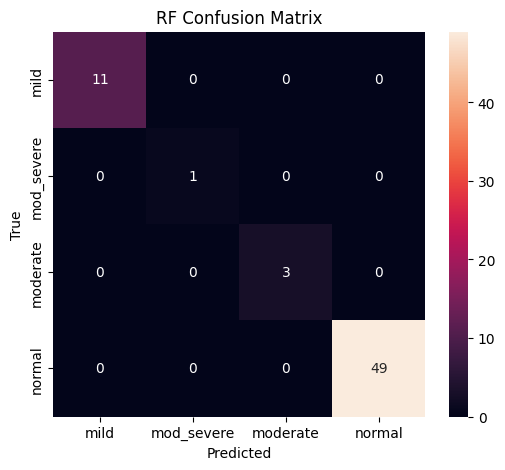

In [ ]:
#@title 8 - Random Forest baseline
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RF Confusion Matrix")
plt.show()

pta_mean              0.342885
air_mean_all          0.150895
bone_1000_hz_right    0.101282
bone_2000_hz_right    0.085603
air_1000_hz_right     0.082680
air_2000_hz_right     0.056529
air_500_hz_right      0.032502
bone_500_hz_right     0.027852
air_8000_hz_right     0.023809
air_4000_hz_right     0.023373
air_250_hz_right      0.022274
air_bone_gap          0.015854
age                   0.013435
bone_4000_hz_right    0.010991
slope_high_low        0.010034
dtype: float64


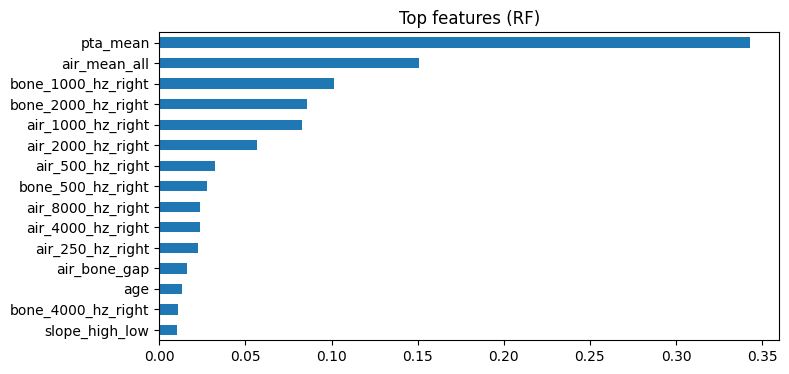

In [ ]:
#@title Feature importance (RF)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feat_imp.head(20))
plt.figure(figsize=(8,4))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top features (RF)")
plt.show()


In [ ]:
joblib.dump({'model': rf, 'label_encoder': le, 'features': X.columns.tolist()}, '/content/rf_audiogram_model.joblib')
print("Saved rf_audiogram_model.joblib")


Saved rf_audiogram_model.joblib


In [ ]:
#@title 9 - XGBoost training
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {
    "objective": "multi:softmax",
    "num_class": len(le.classes_),
    "eta": 0.1,
    "max_depth": 6,
    "eval_metric": "merror",
    "seed": 42
}
bst = xgb.train(params, dtrain, num_boost_round=200)
y_pred_xgb = bst.predict(dtest).astype(int)
print("XGB acc:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

XGB acc: 1.0
              precision    recall  f1-score   support

        mild       1.00      1.00      1.00        11
  mod_severe       1.00      1.00      1.00         1
    moderate       1.00      1.00      1.00         3
      normal       1.00      1.00      1.00        49

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64



In [ ]:
#@title 9b - LightGBM (quick)
lgb_train = lgb.Dataset(X_train_sm, label=y_train_sm)
lgb_eval = lgb.Dataset(X_test, label=y_test, reference=lgb_train)
params_l = {
    'objective': 'multiclass',
    'num_class': len(le.classes_),
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'seed': 42
}
gbm = lgb.train(params_l, lgb_train, num_boost_round=300, valid_sets=[lgb_train, lgb_eval], callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)])
y_pred_lgb = np.argmax(gbm.predict(X_test), axis=1)
print("LGB acc:", accuracy_score(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1497
[LightGBM] [Info] Number of data points in the train set: 772, number of used features: 15
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

In [ ]:
#@title 10 - Prepare sequences for Bi-LSTM (PyTorch or Keras). We'll use Keras.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Sequence columns: choose ordered frequency columns (must be consistent order low->high)
seq_cols = air_cols  # ensure they are ordered low->high; adjust order if needed
print("Sequence columns:", seq_cols)

# prepare arrays
X_seq = df_model[seq_cols].fillna(df_model[seq_cols].mean()).values.astype(np.float32)
y_seq = le.transform(df_model[target_col].astype(str))
y_seq_cat = to_categorical(y_seq, num_classes=len(le.classes_))

# train/test split for sequences (same indices as earlier X_train/X_test if needed)
from sklearn.model_selection import train_test_split
X_seq_train, X_seq_test, y_seq_train, y_seq_test = train_test_split(X_seq, y_seq_cat, test_size=0.2, stratify=y_seq, random_state=42)

# scale sequence features (per-feature)
scaler_seq = StandardScaler()
# reshape to 2D to fit scaler, then reshape back
nsamples, nsteps = X_seq_train.shape
X_seq_train_scaled = scaler_seq.fit_transform(X_seq_train)
X_seq_test_scaled = scaler_seq.transform(X_seq_test)

# LSTM expects shape (samples, timesteps, features). Here features = 1 (threshold per time step)
X_seq_train_scaled = X_seq_train_scaled.reshape(-1, nsteps, 1)
X_seq_test_scaled = X_seq_test_scaled.reshape(-1, nsteps, 1)

# Build Bi-LSTM
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(nsteps,1)))
model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(le.classes_), activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_seq_train_scaled, y_seq_train, validation_split=0.15, epochs=80, batch_size=64, callbacks=[es], verbose=2)


Sequence columns: ['air_250_hz_right', 'bone_500_hz_right', 'air_500_hz_right', 'bone_1000_hz_right', 'air_1000_hz_right', 'bone_2000_hz_right', 'air_2000_hz_right', 'bone_4000_hz_right', 'air_4000_hz_right', 'air_8000_hz_right']


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,308 (165.27 KB)

 Trainable params: 42,308 (165.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
4/4 - 10s - 3s/step - accuracy: 0.3333 - loss: 1.3485 - val_accuracy: 0.7692 - val_loss: 1.2830
Epoch 2/80
4/4 - 1s - 365ms/step - accuracy: 0.7731 - loss: 1.2244 - val_accuracy: 0.7949 - val_loss: 1.1832
Epoch 3/80
4/4 - 0s - 54ms/step - accuracy: 0.7870 - loss: 1.0820 - val_accuracy: 0.7949 - val_loss: 1.0547
Epoch 4/80
4/4 - 0s - 48ms/step - accuracy: 0.8102 - loss: 0.9068 - val_accuracy: 0.7949 - val_loss: 0.9043
Epoch 5/80
4/4 - 0s - 46ms/step - accuracy: 0.8287 - loss: 0.7169 - val_accuracy: 0.7949 - val_loss: 0.7539
Epoch 6/80
4/4 - 0s - 47ms/step - accuracy: 0.8241 - loss: 0.5681 - val_accuracy: 0.7949 - val_loss: 0.6552
Epoch 7/80
4/4 - 0s - 52ms/step - accuracy: 0.8519 - loss: 0.4538 - val_accuracy: 0.7949 - val_loss: 0.6133
Epoch 8/80
4/4 - 0s - 52ms/step - accuracy: 0.8611 - loss: 0.4008 - val_accuracy: 0.8205 - val_loss: 0.5922
Epoch 9/80
4/4 - 0s - 45ms/step - accuracy: 0.8750 - loss: 0.3593 - val_accuracy: 0.8718 - val_loss: 0.5712
Epoch 10/80
4/4 - 0s - 46ms/

In [ ]:
#@title Evaluate Bi-LSTM
loss, acc = model.evaluate(X_seq_test_scaled, y_seq_test, verbose=0)
print("Bi-LSTM test accuracy:", acc)

# Predict & classification report
y_pred_probs = model.predict(X_seq_test_scaled)
y_pred_seq = np.argmax(y_pred_probs, axis=1)
y_true_seq = np.argmax(y_seq_test, axis=1)
print(classification_report(y_true_seq, y_pred_seq, target_names=le.classes_))


Bi-LSTM test accuracy: 0.96875
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 
              precision    recall  f1-score   support

        mild       1.00      0.82      0.90        11
  mod_severe       1.00      1.00      1.00         1
    moderate       0.60      1.00      0.75         3
      normal       1.00      1.00      1.00        49

    accuracy                           0.97        64
   macro avg       0.90      0.95      0.91        64
weighted avg       0.98      0.97      0.97        64



In [ ]:
model.save('/content/bilstm_audiogram_model.h5')
joblib.dump({'scaler_seq': scaler_seq, 'label_encoder': le, 'seq_cols': seq_cols}, '/content/bilstm_meta.joblib')
print("Saved Bi-LSTM model and metadata.")


Saved Bi-LSTM model and metadata.


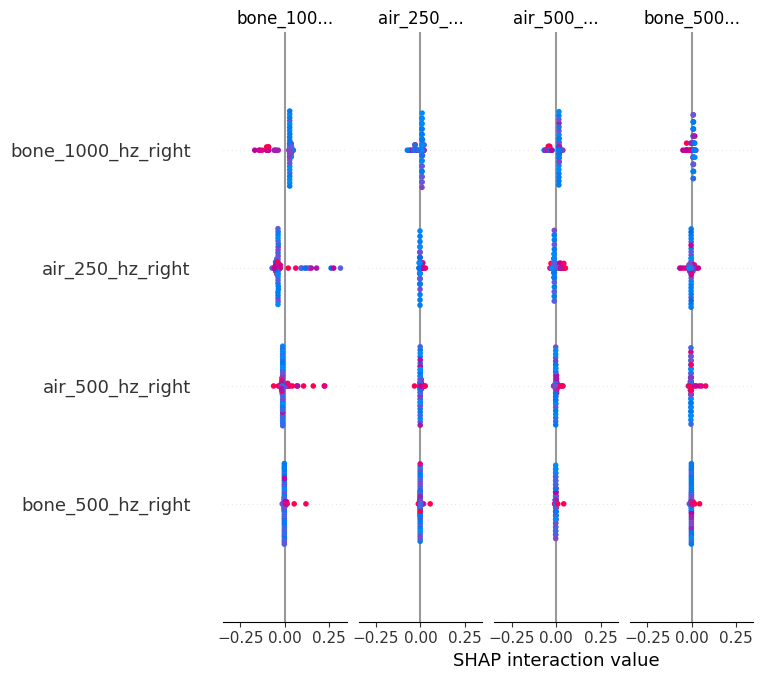

In [ ]:
#@title 11 - SHAP explanation for RF (or LGB)
# Use a subset background to keep compute low
explainer = shap.TreeExplainer(rf)  # use rf or gbm
X_shap_sample = X_test.sample(min(200, X_test.shape[0]), random_state=42)
shap_values = explainer.shap_values(X_shap_sample)

# For multiclass: shap_values is list per class
# Show summary for class 0 as example
if isinstance(shap_values, list):
    cls = 0
    shap.summary_plot(shap_values[cls], X_shap_sample, show=True)
else:
    shap.summary_plot(shap_values, X_shap_sample)


In [ ]:
#@title 12 - 5-fold CV for RandomForest (quick)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y_enc, cv=skf, scoring='accuracy', n_jobs=-1)
print("CV accuracies:", scores)
print("Mean CV accuracy:", np.mean(scores))


CV accuracies: [0.984375   0.984375   1.         0.984375   0.98412698]
Mean CV accuracy: 0.9874503968253968


In [ ]:
#@title 13 - Example inference
# pick a row from X_test
row = X_test.iloc[3]
probs = rf.predict_proba([row.values])[0]
pred_idx = np.argmax(probs)
print("Predicted:", le.inverse_transform([pred_idx])[0], "proba:", probs[pred_idx])

# Bi-LSTM inference (sequence)
# prepare sequence vector
seq_row = df_model[seq_cols].fillna(df_model[seq_cols].mean()).iloc[3].values.astype(np.float32).reshape(1, nsteps)
seq_scaled = scaler_seq.transform(seq_row).reshape(1, nsteps, 1)
pred_bilstm = model.predict(seq_scaled)
print("Bi-LSTM predicted:", le.inverse_transform([np.argmax(pred_bilstm)])[0], "proba:", np.max(pred_bilstm))


Predicted: mild proba: 0.89
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
Bi-LSTM predicted: normal proba: 0.9999999


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Model Performance Comparison:


,Model,Accuracy (%),F1-Score
0,Random Forest,100.000,1.000
1,XGBoost,100.000,1.000
2,LightGBM,100.000,1.000
3,Bi-LSTM,96.875,0.971


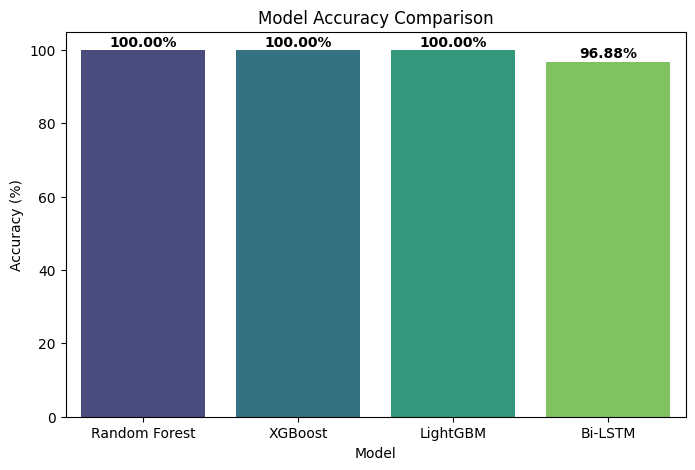

In [ ]:
#@title 16 - Model accuracy comparison for conclusion

# --- Collect model performance metrics ---
from sklearn.metrics import accuracy_score, f1_score

# 1️⃣ Random Forest
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# 2️⃣ XGBoost
try:
    y_pred_xgb = bst.predict(xgb.DMatrix(X_test))
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
except:
    acc_xgb, f1_xgb = np.nan, np.nan

# 3️⃣ LightGBM
try:
    y_pred_lgb = np.argmax(gbm.predict(X_test), axis=1)
    acc_lgb = accuracy_score(y_test, y_pred_lgb)
    f1_lgb = f1_score(y_test, y_pred_lgb, average='weighted')
except:
    acc_lgb, f1_lgb = np.nan, np.nan

# 4️⃣ Bi-LSTM
try:
    y_pred_bilstm = np.argmax(model.predict(X_seq_test_scaled), axis=1)
    y_true_bilstm = np.argmax(y_seq_test, axis=1)
    acc_bilstm = accuracy_score(y_true_bilstm, y_pred_bilstm)
    f1_bilstm = f1_score(y_true_bilstm, y_pred_bilstm, average='weighted')
except:
    acc_bilstm, f1_bilstm = np.nan, np.nan

# --- Combine results into a dataframe ---
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'Bi-LSTM'],
    'Accuracy (%)': [acc_rf*100, acc_xgb*100, acc_lgb*100, acc_bilstm*100],
    'F1-Score': [f1_rf, f1_xgb, f1_lgb, f1_bilstm]
}).round(3)

# --- Display comparison table ---
print("\nModel Performance Comparison:")
display(results)

# --- Plot bar chart ---
plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Model', y='Accuracy (%)', palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
for i, v in enumerate(results['Accuracy (%)']):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()


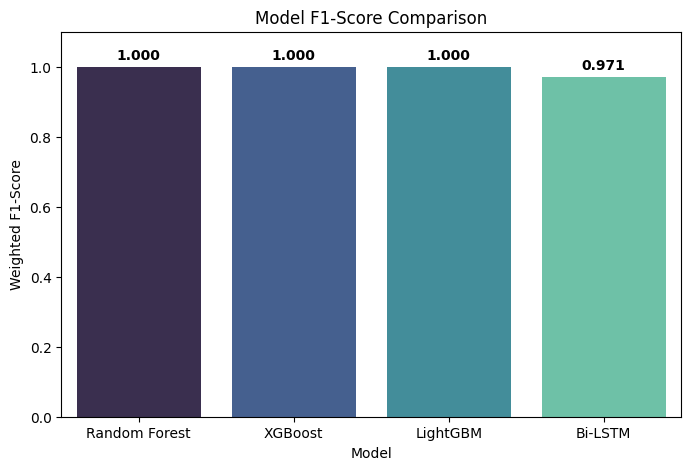

In [ ]:
#@title (Optional) F1-score comparison plot
plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Model', y='F1-Score', palette='mako')
plt.title("Model F1-Score Comparison")
plt.ylabel("Weighted F1-Score")
plt.ylim(0, 1.1)
for i, v in enumerate(results['F1-Score']):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()


🏆 Best Performing Model: Random Forest

Accuracy: 100.00%
Weighted F1-Score: 1.000

Classification Report:

              precision    recall  f1-score   support

        mild       1.00      1.00      1.00        11
  mod_severe       1.00      1.00      1.00         1
    moderate       1.00      1.00      1.00         3
      normal       1.00      1.00      1.00        49

    accuracy                           1.00        64
   macro avg       1.00      1.00      1.00        64
weighted avg       1.00      1.00      1.00        64



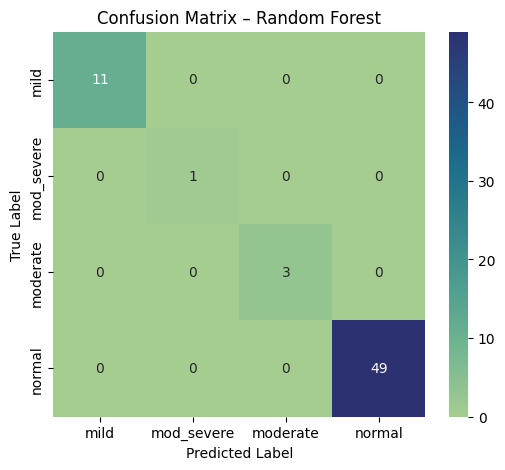

In [ ]:
#@title 17 - Confusion Matrix & Report for Best Model

from sklearn.metrics import confusion_matrix, classification_report

# --- Identify best model from results table ---
best_model_name = results.loc[results['Accuracy (%)'].idxmax(), 'Model']
print(f"🏆 Best Performing Model: {best_model_name}")

# --- Generate predictions & true labels for the best model ---
if best_model_name == 'Random Forest':
    y_true_best, y_pred_best = y_test, y_pred_rf

elif best_model_name == 'XGBoost':
    y_true_best, y_pred_best = y_test, y_pred_xgb

elif best_model_name == 'LightGBM':
    y_true_best, y_pred_best = y_test, y_pred_lgb

elif best_model_name == 'Bi-LSTM':
    y_true_best, y_pred_best = y_true_bilstm, y_pred_bilstm

else:
    raise ValueError("Unknown best model name detected.")

# --- Compute confusion matrix ---
cm_best = confusion_matrix(y_true_best, y_pred_best)
acc_best = accuracy_score(y_true_best, y_pred_best)
f1_best = f1_score(y_true_best, y_pred_best, average='weighted')

# --- Display metrics ---
print(f"\nAccuracy: {acc_best*100:.2f}%")
print(f"Weighted F1-Score: {f1_best:.3f}")
print("\nClassification Report:\n")
print(classification_report(y_true_best, y_pred_best, target_names=le.classes_))

# --- Plot confusion matrix ---
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='crest',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()
